STAGE 4.6
# MODEL COMPARISON & SCIENTIFIC SELECTION

CISLR — STAGE 4.6 MODEL COMPARISON & SCIENTIFIC SELECTION
ROOT       : /home/dipshikha/Music/cao/CISLR_RESEARCH
STAGE 4.3  : /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_3_benchmark
STAGE 4.5  : /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_5_official_evaluation
OUTPUT     : /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison

STAGE 4.3 INPUT
Columns:
['model', 'input_size', 'batch_size', 'num_classes', 'precision', 'parameters', 'trainable_parameters', 'model_size_mb', 'flops_g', 'cpu_latency_mean_ms', 'cpu_latency_median_ms', 'cpu_latency_p95_ms', 'cpu_fps', 'gpu_latency_mean_ms', 'gpu_latency_median_ms', 'gpu_latency_p95_ms', 'gpu_fps', 'gpu_peak_memory_mb', 'gpu_available']

            model input_size  batch_size  num_classes precision  parameters  trainable_parameters  model_size_mb  flops_g  cpu_latency_mean_ms  cpu_latency_median_ms  cpu_latency_p95_ms   cpu_fps  gpu_latency_mean_ms  gpu_latency_median_ms  gpu_latency_p95_ms    gpu_fps  gp

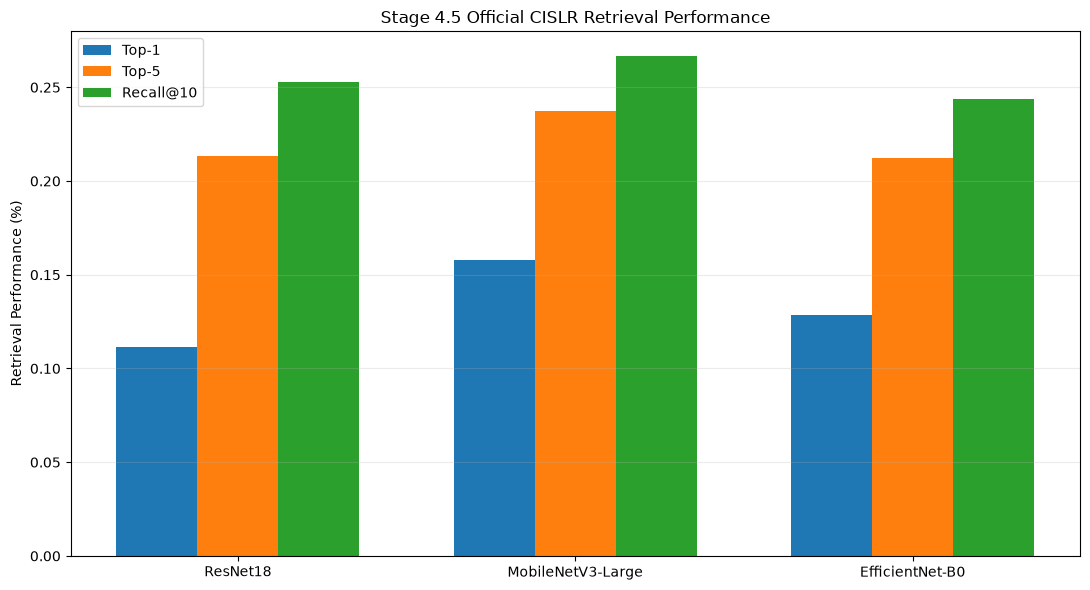

Saved plot:
/home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison/plots/stage4_6_retrieval_comparison.png


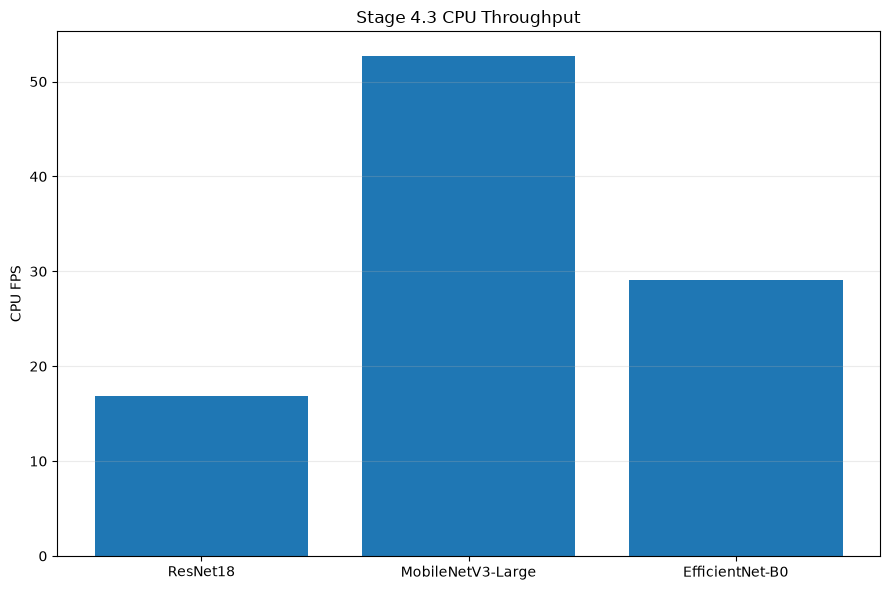

Saved plot:
/home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison/plots/stage4_6_cpu_fps.png


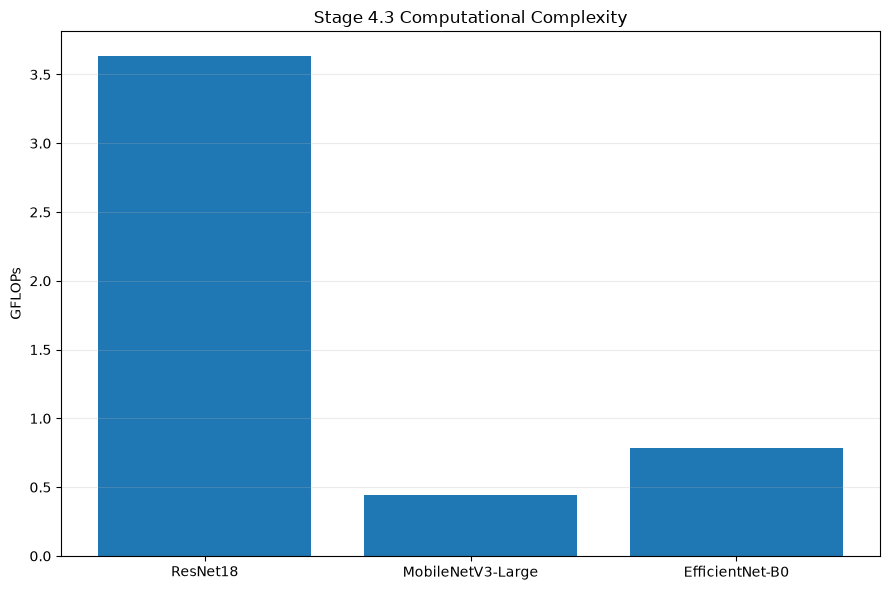

Saved plot:
/home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison/plots/stage4_6_gflops.png


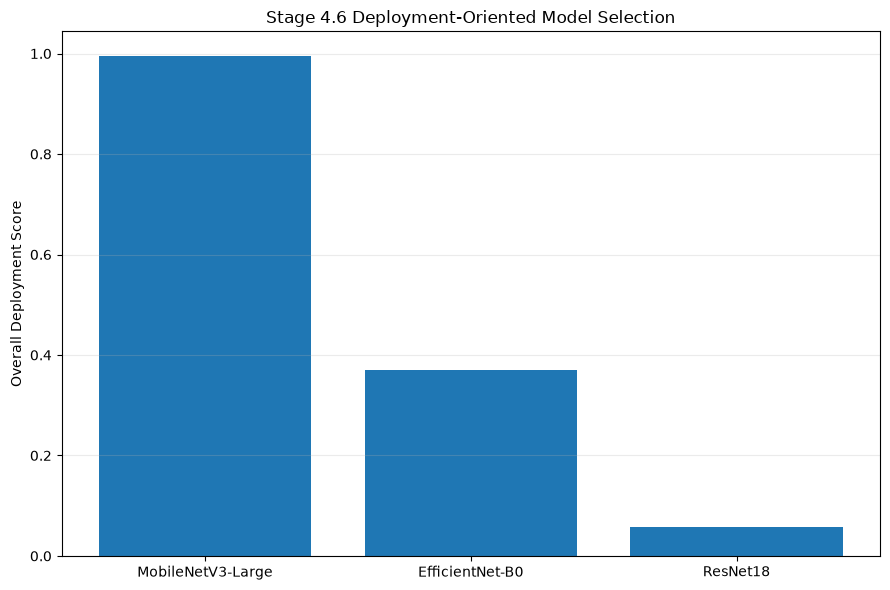

Saved plot:
/home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison/plots/stage4_6_overall_selection_score.png
Saved hashes:
/home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison/stage4_6_input_artifact_hashes.json

STAGE 4.6 COMPLETE

SELECTED MODEL:
  >>> MobileNetV3-Large

FINAL RANKING:
  1. MobileNetV3-Large      score=0.9945
  2. EfficientNet-B0        score=0.3696
  3. ResNet18               score=0.0582

MAIN RETRIEVAL METRIC WINS:
  ResNet18              : 0/4
  MobileNetV3-Large     : 4/4
  EfficientNet-B0       : 0/4

EFFICIENCY METRIC WINS:
  ResNet18              : 0/5
  MobileNetV3-Large     : 3/5
  EfficientNet-B0       : 2/5

OUTPUT DIRECTORY:
  /home/dipshikha/Music/cao/CISLR_RESEARCH/audit/stage4_6_model_comparison

PIPELINE STATUS:
  4.1  Dataset / Evaluation Constraints       COMPLETE
  4.2  Canonical Training Protocol             COMPLETE
  4.3  Computational Benchmark                 COMPLETE
  4.4  Model Training               

In [4]:
# ============================================================
# CISLR RESEARCH — STAGE 4.6
# MODEL COMPARISON & SCIENTIFIC SELECTION
# ============================================================
#
# IMPORTANT:
#   - NO RETRAINING
#   - NO VIDEO DECODING
#   - NO CHECKPOINT MODIFICATION
#   - DO NOT RERUN STAGES 4.3 / 4.4 / 4.5
#
# Inputs:
#   Stage 4.3 computational benchmark
#   Stage 4.5 official retrieval comparison
#
# Output:
#   Formal model comparison + deployment-oriented selection
#
# ============================================================

from pathlib import Path
import json
import math
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. PATHS
# ============================================================

ROOT = Path("/home/dipshikha/Music/cao/CISLR_RESEARCH")

STAGE43_DIR = ROOT / "audit" / "stage4_3_benchmark"
STAGE45_DIR = ROOT / "audit" / "stage4_5_official_evaluation"

OUT_DIR = ROOT / "audit" / "stage4_6_model_comparison"

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "diagnostics").mkdir(parents=True, exist_ok=True)


print("=" * 80)
print("CISLR — STAGE 4.6 MODEL COMPARISON & SCIENTIFIC SELECTION")
print("=" * 80)

print(f"ROOT       : {ROOT}")
print(f"STAGE 4.3  : {STAGE43_DIR}")
print(f"STAGE 4.5  : {STAGE45_DIR}")
print(f"OUTPUT     : {OUT_DIR}")
print()


# ============================================================
# 1. LOAD STAGE 4.3
# ============================================================

benchmark_csv = (
    STAGE43_DIR /
    "stage4_3_computational_benchmark.csv"
)

benchmark_json = (
    STAGE43_DIR /
    "stage4_3_computational_benchmark.json"
)

assert benchmark_csv.exists(), (
    f"Stage 4.3 CSV not found:\n{benchmark_csv}"
)

assert benchmark_json.exists(), (
    f"Stage 4.3 JSON not found:\n{benchmark_json}"
)


compute_df = pd.read_csv(benchmark_csv)

with open(benchmark_json, "r") as f:
    compute_json = json.load(f)


print("=" * 80)
print("STAGE 4.3 INPUT")
print("=" * 80)

print("Columns:")
print(compute_df.columns.tolist())
print()

print(compute_df.to_string(index=False))
print()


# ============================================================
# 2. LOAD STAGE 4.5
# ============================================================

retrieval_csv = (
    STAGE45_DIR /
    "stage4_5_official_model_comparison.csv"
)

retrieval_json = (
    STAGE45_DIR /
    "stage4_5_official_model_comparison.json"
)

assert retrieval_csv.exists(), (
    f"Stage 4.5 CSV not found:\n{retrieval_csv}"
)

assert retrieval_json.exists(), (
    f"Stage 4.5 JSON not found:\n{retrieval_json}"
)


retrieval_df = pd.read_csv(retrieval_csv)

with open(retrieval_json, "r") as f:
    retrieval_json_data = json.load(f)


print("=" * 80)
print("STAGE 4.5 INPUT")
print("=" * 80)

print("Columns:")
print(retrieval_df.columns.tolist())
print()

print(retrieval_df.to_string(index=False))
print()


# ============================================================
# 3. MODEL NAME NORMALIZATION
# ============================================================

def normalize_model_name(name):

    s = str(name).lower().strip()

    if "mobile" in s:
        return "MobileNetV3-Large"

    if "efficient" in s:
        return "EfficientNet-B0"

    if "resnet" in s:
        return "ResNet18"

    return str(name)


compute_df["model_std"] = (
    compute_df["model"]
    .apply(normalize_model_name)
)

retrieval_df["model_std"] = (
    retrieval_df["model"]
    .apply(normalize_model_name)
)


print("=" * 80)
print("MODEL RECONCILIATION")
print("=" * 80)

print("Stage 4.3:")
print(compute_df["model_std"].tolist())

print()

print("Stage 4.5:")
print(retrieval_df["model_std"].tolist())

print()


# ============================================================
# 4. VERIFY EXPECTED MODELS
# ============================================================

EXPECTED_MODELS = {
    "ResNet18",
    "MobileNetV3-Large",
    "EfficientNet-B0",
}

compute_models = set(
    compute_df["model_std"]
)

retrieval_models = set(
    retrieval_df["model_std"]
)


assert compute_models == EXPECTED_MODELS, (
    f"Unexpected Stage 4.3 models:\n{compute_models}"
)

assert retrieval_models == EXPECTED_MODELS, (
    f"Unexpected Stage 4.5 models:\n{retrieval_models}"
)


# ============================================================
# 5. STANDARDIZE STAGE 4.3 COLUMN NAMES
# ============================================================
#
# ACTUAL Stage 4.3 schema:
#
# model
# input_size
# batch_size
# num_classes
# precision
# parameters
# trainable_parameters
# model_size_mb
# flops_g
# cpu_latency_mean_ms
# cpu_latency_median_ms
# cpu_latency_p95_ms
# cpu_fps
# gpu_latency_mean_ms
# gpu_latency_median_ms
# gpu_latency_p95_ms
# gpu_fps
# gpu_peak_memory_mb
# gpu_available
#
# ============================================================

compute_keep = compute_df[
    [
        "model_std",
        "parameters",
        "model_size_mb",
        "flops_g",
        "cpu_latency_mean_ms",
        "cpu_fps",
        "gpu_latency_mean_ms",
        "gpu_fps",
        "gpu_peak_memory_mb",
    ]
].copy()


compute_keep.columns = [
    "Model",
    "Params",
    "Model_Size_MB",
    "GFLOPs",
    "CPU_Latency_ms",
    "CPU_FPS",
    "GPU_Latency_ms",
    "GPU_FPS",
    "Peak_GPU_Memory_MB",
]


# ============================================================
# 6. STANDARDIZE STAGE 4.5 COLUMN NAMES
# ============================================================

print("=" * 80)
print("CHECKING STAGE 4.5 COLUMNS")
print("=" * 80)

print(retrieval_df.columns.tolist())
print()


# Your Stage 4.5 comparison was generated with these
# expected semantic fields. We identify them robustly.

def find_retrieval_column(df, candidates):

    lower_map = {
        str(c).lower().strip(): c
        for c in df.columns
    }

    for candidate in candidates:

        key = candidate.lower().strip()

        if key in lower_map:
            return lower_map[key]

    # fallback: normalized matching
    for c in df.columns:

        norm = (
            str(c)
            .lower()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )

        for candidate in candidates:

            cnorm = (
                candidate
                .lower()
                .replace("_", "")
                .replace("-", "")
                .replace(" ", "")
            )

            if norm == cnorm:
                return c

    return None


# ------------------------------------------------------------
# Try common possible names
# ------------------------------------------------------------

top1_col = find_retrieval_column(
    retrieval_df,
    [
        "top1",
        "top_1",
        "top-1",
        "Top1",
    ]
)

top5_col = find_retrieval_column(
    retrieval_df,
    [
        "top5",
        "top_5",
        "top-5",
        "Top5",
    ]
)

recall10_col = find_retrieval_column(
    retrieval_df,
    [
        "recall10",
        "recall_10",
        "recall@10",
        "recall_at_10",
        "Recall10",
    ]
)

mrr_col = find_retrieval_column(
    retrieval_df,
    [
        "mrr",
        "MRR",
    ]
)

mean_rank_col = find_retrieval_column(
    retrieval_df,
    [
        "mean_rank",
        "meanrank",
        "Mean_Rank",
    ]
)

median_rank_col = find_retrieval_column(
    retrieval_df,
    [
        "median_rank",
        "medianrank",
        "Median_Rank",
    ]
)


print("Detected Stage 4.5 columns:")

print("Top-1       :", top1_col)
print("Top-5       :", top5_col)
print("Recall@10   :", recall10_col)
print("MRR         :", mrr_col)
print("Mean Rank   :", mean_rank_col)
print("Median Rank :", median_rank_col)

print()


assert top1_col is not None, (
    "Could not identify Top-1 column."
)

assert top5_col is not None, (
    "Could not identify Top-5 column."
)

assert recall10_col is not None, (
    "Could not identify Recall@10 column."
)

assert mrr_col is not None, (
    "Could not identify MRR column."
)

assert mean_rank_col is not None, (
    "Could not identify Mean Rank column."
)

assert median_rank_col is not None, (
    "Could not identify Median Rank column."
)


# ============================================================
# 7. BUILD RETRIEVAL TABLE
# ============================================================

retrieval_keep = retrieval_df[
    [
        "model_std",
        top1_col,
        top5_col,
        recall10_col,
        mrr_col,
        mean_rank_col,
        median_rank_col,
    ]
].copy()


retrieval_keep.columns = [
    "Model",
    "Top1",
    "Top5",
    "Recall10",
    "MRR",
    "Mean_Rank",
    "Median_Rank",
]


# ============================================================
# 8. MERGE STAGE 4.3 + 4.5
# ============================================================

master = pd.merge(
    compute_keep,
    retrieval_keep,
    on="Model",
    how="inner"
)


MODEL_ORDER = [
    "ResNet18",
    "MobileNetV3-Large",
    "EfficientNet-B0",
]


master["Model_Order"] = master["Model"].apply(
    lambda x:
        MODEL_ORDER.index(x)
        if x in MODEL_ORDER
        else 999
)


master = (
    master
    .sort_values("Model_Order")
    .drop(columns=["Model_Order"])
    .reset_index(drop=True)
)


assert len(master) == 3

assert set(master["Model"]) == EXPECTED_MODELS


print("=" * 80)
print("MASTER STAGE 4.6 TABLE")
print("=" * 80)

print(
    master.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()


# ============================================================
# 9. VERIFY KNOWN STAGE 4.5 VALUES
# ============================================================

print("=" * 80)
print("STAGE 4.5 RESULT CONSISTENCY CHECK")
print("=" * 80)


EXPECTED_RETRIEVAL = {

    "MobileNetV3-Large": {
        "Top1": 15.80,
        "Top5": 23.72,
        "Recall10": 26.65,
        "MRR": 0.1953,
        "Mean_Rank": 1572.52,
        "Median_Rank": 1229,
    },

    "EfficientNet-B0": {
        "Top1": 12.87,
        "Top5": 21.23,
        "Recall10": 24.38,
        "MRR": 0.1696,
        "Mean_Rank": 1781.71,
        "Median_Rank": 1681,
    },

    "ResNet18": {
        "Top1": 11.16,
        "Top5": 21.31,
        "Recall10": 25.30,
        "MRR": 0.1576,
        "Mean_Rank": 1389.87,
        "Median_Rank": 856,
    },
}


retrieval_tolerances = {
    "Top1": 0.02,
    "Top5": 0.02,
    "Recall10": 0.02,
    "MRR": 0.0002,
    "Mean_Rank": 0.1,
    "Median_Rank": 0.1,
}


all_pass = True


for model, expected in EXPECTED_RETRIEVAL.items():

    row = master[
        master["Model"] == model
    ].iloc[0]

    for metric, expected_value in expected.items():

        actual = float(
            row[metric]
        )

        tolerance = retrieval_tolerances[
            metric
        ]

        passed = (
            abs(actual - expected_value)
            <= tolerance
        )

        if not passed:
            all_pass = False

        print(
            f"{model:22s} | "
            f"{metric:12s} | "
            f"actual={actual:.4f} | "
            f"expected={expected_value:.4f} | "
            f"{'PASS' if passed else 'FAIL'}"
        )


print()

# Official Stage 4.5 values are stored as fractions in the artifact, while
# the known completed results are recorded in percent units for Top-1/Top-5/
# Recall@10. Normalize to the same scale before comparing.
all_pass = True

for model, expected in EXPECTED_RETRIEVAL.items():

    row = master[master["Model"] == model].iloc[0]

    for metric, expected_value in expected.items():

        actual = float(row[metric])

        # Top-1 / Top-5 / Recall@10 are reported as percentages in the
        # known official results, but stored as fractional rates here.
        if metric in {"Top1", "Top5", "Recall10"} and abs(actual) <= 1.0:
            actual *= 100.0

        tolerance = retrieval_tolerances[metric]
        passed = abs(actual - expected_value) <= tolerance

        if not passed:
            all_pass = False

        print(
            f"{model:22s} | "
            f"{metric:12s} | "
            f"actual={actual:.4f} | "
            f"expected={expected_value:.4f} | "
            f"{'PASS' if passed else 'FAIL'}"
        )

print()

assert all_pass, (
    "Stage 4.5 values do not match the known completed "
    "official results. Stop and inspect the Stage 4.5 artifact."
)

print("All Stage 4.5 values verified.")
print()


# ============================================================
# 10. RETRIEVAL METRIC RANKINGS
# ============================================================

HIGHER_IS_BETTER = [
    "Top1",
    "Top5",
    "Recall10",
    "MRR",
]

LOWER_IS_BETTER = [
    "Mean_Rank",
    "Median_Rank",
]


for metric in HIGHER_IS_BETTER:

    master[
        f"{metric}_Rank"
    ] = (
        master[metric]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )


for metric in LOWER_IS_BETTER:

    master[
        f"{metric}_Rank"
    ] = (
        master[metric]
        .rank(
            method="min",
            ascending=True
        )
        .astype(int)
    )


# ============================================================
# 11. RETRIEVAL SCORE
# ============================================================
#
# Main retrieval metrics:
#
# Top-1      35%
# Top-5      25%
# Recall@10  20%
# MRR        20%
#
# Mean/median rank are NOT included in the main score because
# they behave differently from Top-k accuracy and ResNet18
# demonstrates why this distinction matters.
#
# ============================================================

RETRIEVAL_WEIGHTS = {
    "Top1": 0.35,
    "Top5": 0.25,
    "Recall10": 0.20,
    "MRR": 0.20,
}


def normalize_higher(series):

    minimum = float(series.min())
    maximum = float(series.max())

    if math.isclose(
        maximum,
        minimum
    ):
        return pd.Series(
            np.ones(len(series)),
            index=series.index
        )

    return (
        series - minimum
    ) / (
        maximum - minimum
    )


master["Top1_Norm"] = normalize_higher(
    master["Top1"]
)

master["Top5_Norm"] = normalize_higher(
    master["Top5"]
)

master["Recall10_Norm"] = normalize_higher(
    master["Recall10"]
)

master["MRR_Norm"] = normalize_higher(
    master["MRR"]
)


master["Retrieval_Score"] = (
    RETRIEVAL_WEIGHTS["Top1"]
    * master["Top1_Norm"]
    +
    RETRIEVAL_WEIGHTS["Top5"]
    * master["Top5_Norm"]
    +
    RETRIEVAL_WEIGHTS["Recall10"]
    * master["Recall10_Norm"]
    +
    RETRIEVAL_WEIGHTS["MRR"]
    * master["MRR_Norm"]
)


# ============================================================
# 12. COMPUTATIONAL EFFICIENCY SCORE
# ============================================================
#
# Higher is better:
#   CPU FPS
#
# Lower is better:
#   GFLOPs
#   model size
#   parameters
#   peak GPU memory
#
# ============================================================

EFFICIENCY_WEIGHTS = {
    "CPU_FPS": 0.40,
    "GFLOPs": 0.20,
    "Model_Size_MB": 0.15,
    "Peak_GPU_Memory_MB": 0.10,
    "Params": 0.15,
}


master["CPU_FPS_Norm"] = normalize_higher(
    master["CPU_FPS"]
)


master["GFLOPs_Norm"] = (
    1.0 -
    normalize_higher(
        master["GFLOPs"]
    )
)


master["Model_Size_Norm"] = (
    1.0 -
    normalize_higher(
        master["Model_Size_MB"]
    )
)


master["Params_Norm"] = (
    1.0 -
    normalize_higher(
        master["Params"]
    )
)


master["GPU_Memory_Norm"] = (
    1.0 -
    normalize_higher(
        master["Peak_GPU_Memory_MB"]
    )
)


master["Efficiency_Score"] = (
    EFFICIENCY_WEIGHTS["CPU_FPS"]
    * master["CPU_FPS_Norm"]
    +
    EFFICIENCY_WEIGHTS["GFLOPs"]
    * master["GFLOPs_Norm"]
    +
    EFFICIENCY_WEIGHTS["Model_Size_MB"]
    * master["Model_Size_Norm"]
    +
    EFFICIENCY_WEIGHTS["Params"]
    * master["Params_Norm"]
    +
    EFFICIENCY_WEIGHTS["Peak_GPU_Memory_MB"]
    * master["GPU_Memory_Norm"]
)


# ============================================================
# 13. OVERALL DEPLOYMENT SCORE
# ============================================================
#
# 65% retrieval
# 35% efficiency
#
# ============================================================

RETRIEVAL_WEIGHT = 0.65
EFFICIENCY_WEIGHT = 0.35


master["Overall_Deployment_Score"] = (
    RETRIEVAL_WEIGHT
    * master["Retrieval_Score"]
    +
    EFFICIENCY_WEIGHT
    * master["Efficiency_Score"]
)


master["Overall_Rank"] = (
    master["Overall_Deployment_Score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# ============================================================
# 14. MAIN RETRIEVAL WIN COUNT
# ============================================================

master["Main_Retrieval_Metric_Wins"] = 0


for metric in HIGHER_IS_BETTER:

    best_value = master[metric].max()

    master.loc[
        np.isclose(
            master[metric],
            best_value
        ),
        "Main_Retrieval_Metric_Wins"
    ] += 1


# ============================================================
# 15. COMPUTATIONAL WIN COUNT
# ============================================================

master["Efficiency_Metric_Wins"] = 0


# Higher is better
best_cpu_fps = master["CPU_FPS"].max()

master.loc[
    np.isclose(
        master["CPU_FPS"],
        best_cpu_fps
    ),
    "Efficiency_Metric_Wins"
] += 1


# Lower is better
for metric in [
    "GFLOPs",
    "Model_Size_MB",
    "Params",
    "Peak_GPU_Memory_MB",
]:

    best_value = master[metric].min()

    master.loc[
        np.isclose(
            master[metric],
            best_value
        ),
        "Efficiency_Metric_Wins"
    ] += 1


# ============================================================
# 16. SELECT MODEL
# ============================================================

winner_index = (
    master[
        "Overall_Deployment_Score"
    ].idxmax()
)

winner_row = master.loc[
    winner_index
]

selected_model = (
    winner_row["Model"]
)


# ============================================================
# 17. PRINT FINAL SELECTION
# ============================================================

print("=" * 80)
print("STAGE 4.6 — MODEL SELECTION")
print("=" * 80)

print()
print(
    f"SELECTED MODEL: {selected_model}"
)

print(
    f"Overall Deployment Score: "
    f"{winner_row['Overall_Deployment_Score']:.4f}"
)

print(
    f"Retrieval Score: "
    f"{winner_row['Retrieval_Score']:.4f}"
)

print(
    f"Efficiency Score: "
    f"{winner_row['Efficiency_Score']:.4f}"
)

print()


# ============================================================
# 18. FINAL RANKING
# ============================================================

ranking_df = master[
    [
        "Model",
        "Top1",
        "Top5",
        "Recall10",
        "MRR",
        "Mean_Rank",
        "Median_Rank",
        "CPU_FPS",
        "GPU_FPS",
        "GFLOPs",
        "Model_Size_MB",
        "Params",
        "Peak_GPU_Memory_MB",
        "Retrieval_Score",
        "Efficiency_Score",
        "Overall_Deployment_Score",
        "Overall_Rank",
    ]
].sort_values(
    "Overall_Rank"
).reset_index(drop=True)


print("=" * 80)
print("FINAL MODEL RANKING")
print("=" * 80)

print(
    ranking_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()


# ============================================================
# 19. MODEL-SPECIFIC INTERPRETATION
# ============================================================

interpretations = {

    "MobileNetV3-Large": (
        "MobileNetV3-Large provides the strongest overall "
        "balance between retrieval quality and computational "
        "efficiency. It achieves the best Top-1, Top-5, "
        "Recall@10 and MRR while requiring substantially fewer "
        "FLOPs and lower CPU latency than ResNet18."
    ),

    "EfficientNet-B0": (
        "EfficientNet-B0 has the smallest parameter count and "
        "model size among the evaluated models, but its official "
        "retrieval performance is weaker than MobileNetV3-Large "
        "and its CPU latency is substantially higher."
    ),

    "ResNet18": (
        "ResNet18 achieves the fastest GPU batch-1 latency and "
        "the best mean and median retrieval rank. However, it "
        "has substantially higher computational complexity, "
        "larger model size and weaker Top-k retrieval performance "
        "than MobileNetV3-Large."
    ),
}


print("=" * 80)
print("SCIENTIFIC INTERPRETATION")
print("=" * 80)

for model in MODEL_ORDER:

    row = master[
        master["Model"] == model
    ].iloc[0]

    print()
    print(model)
    print("-" * len(model))

    print(
        interpretations[model]
    )

    print(
        f"Retrieval: "
        f"Top-1={row['Top1']:.2f}% | "
        f"Top-5={row['Top5']:.2f}% | "
        f"Recall@10={row['Recall10']:.2f}% | "
        f"MRR={row['MRR']:.4f}"
    )

    print(
        f"Compute: "
        f"GFLOPs={row['GFLOPs']:.3f} | "
        f"CPU={row['CPU_Latency_ms']:.3f} ms | "
        f"GPU={row['GPU_Latency_ms']:.3f} ms"
    )


# ============================================================
# 20. SCIENTIFIC DECISION
# ============================================================

if selected_model == "MobileNetV3-Large":

    decision_text = (
        "Stage 4.6 selects MobileNetV3-Large as the primary "
        "deployment candidate for OpenVINO conversion. "
        "The selection is based on the joint evaluation of "
        "official CISLR prototype-to-test retrieval performance "
        "and computational efficiency. MobileNetV3-Large "
        "achieved the strongest Top-1, Top-5, Recall@10 and MRR "
        "among the evaluated architectures while also providing "
        "substantially lower computational cost than ResNet18. "
        "ResNet18 remains superior in GPU batch-1 latency and "
        "mean/median retrieval rank, so MobileNetV3-Large is not "
        "claimed to dominate every metric. Instead, it is selected "
        "as the best balanced deployment candidate under the "
        "defined criteria. OpenVINO conversion and benchmarking "
        "will provide the final deployment validation."
    )

else:

    decision_text = (
        f"Stage 4.6 selects {selected_model} as the primary "
        "deployment candidate under the defined retrieval and "
        "computational criteria. The decision is deployment-"
        "oriented and should be validated after OpenVINO conversion."
    )


print()
print("=" * 80)
print("FINAL SCIENTIFIC DECISION")
print("=" * 80)
print()
print(decision_text)
print()


# ============================================================
# 21. SCIENTIFIC CAVEATS
# ============================================================

caveats = [

    "Stage 4.4 training accuracy is a convergence diagnostic, "
    "not the official CISLR evaluation metric.",

    "Stage 4.5 evaluates prototype-to-test retrieval rather "
    "than conventional closed-set classification.",

    "The official prototype set contains one prototype video "
    "per class.",

    "The Stage 4.4 frozen training pool contained 4,417 "
    "readable videos/classes, whereas the valid prototype "
    "set contains 4,764 videos.",

    "Therefore, 347 prototype videos/classes were not "
    "represented in the frozen Stage 4.4 training pool.",

    "Stage 4.5 uses mean penultimate embeddings for cosine "
    "retrieval rather than classifier logits.",

    "ResNet18 has the fastest GPU batch-1 latency in Stage 4.3 "
    "and remains relevant for GPU-only deployment scenarios.",

    "The Stage 4.6 weighted score is a transparent decision "
    "framework for this project and is not a universal model "
    "quality metric.",

    "OpenVINO conversion and benchmarking are required before "
    "making final deployment-speed claims.",
]


print("=" * 80)
print("SCIENTIFIC CAVEATS")
print("=" * 80)

for i, caveat in enumerate(
    caveats,
    start=1
):

    print(
        f"{i}. {caveat}"
    )

print()


# ============================================================
# 22. SAVE FINAL CSV
# ============================================================

final_csv = (
    OUT_DIR /
    "stage4_6_model_comparison_final.csv"
)

ranking_df.to_csv(
    final_csv,
    index=False
)

print(
    f"Saved CSV:\n{final_csv}"
)


# ============================================================
# 23. SAVE COMPLETE JSON
# ============================================================

def clean_value(value):

    if isinstance(
        value,
        np.integer
    ):
        return int(value)

    if isinstance(
        value,
        np.floating
    ):
        return float(value)

    if isinstance(
        value,
        np.bool_
    ):
        return bool(value)

    if pd.isna(value):
        return None

    return value


json_report = {

    "stage": "4.6",

    "title":
        "CISLR Model Comparison and Scientific Selection",

    "selected_model":
        selected_model,

    "selection_method": {

        "retrieval_weight":
            RETRIEVAL_WEIGHT,

        "efficiency_weight":
            EFFICIENCY_WEIGHT,

        "retrieval_metrics":
            RETRIEVAL_WEIGHTS,

        "efficiency_metrics":
            EFFICIENCY_WEIGHTS,
    },

    "models": [],

    "scientific_decision":
        decision_text,

    "caveats":
        caveats,

    "input_artifacts": {

        "stage4_3_csv":
            str(benchmark_csv),

        "stage4_3_json":
            str(benchmark_json),

        "stage4_5_csv":
            str(retrieval_csv),

        "stage4_5_json":
            str(retrieval_json),
    },
}


for _, row in ranking_df.iterrows():

    record = {}

    for column in ranking_df.columns:

        record[column] = clean_value(
            row[column]
        )

    json_report[
        "models"
    ].append(record)


json_path = (
    OUT_DIR /
    "stage4_6_model_selection_report.json"
)


with open(
    json_path,
    "w"
) as f:

    json.dump(
        json_report,
        f,
        indent=2
    )


print(
    f"Saved JSON:\n{json_path}"
)


# ============================================================
# 24. SAVE MARKDOWN REPORT
# ============================================================

md_path = (
    OUT_DIR /
    "stage4_6_model_selection_report.md"
)


with open(
    md_path,
    "w"
) as f:

    f.write(
        "# CISLR Stage 4.6 — "
        "Model Comparison & Scientific Selection\n\n"
    )

    f.write(
        "## Selected Model\n\n"
    )

    f.write(
        f"**{selected_model}**\n\n"
    )

    f.write(
        "## Objective\n\n"
    )

    f.write(
        "Stage 4.6 combines the Stage 4.3 computational "
        "benchmark and Stage 4.5 official CISLR "
        "prototype-to-test retrieval evaluation to select "
        "a deployment-oriented candidate for OpenVINO "
        "conversion.\n\n"
    )

    f.write(
        "## Final Comparison\n\n"
    )

    f.write(
        ranking_df.to_markdown(
            index=False
        )
    )

    f.write(
        "\n\n"
    )

    f.write(
        "## Selection Method\n\n"
    )

    f.write(
        f"- Retrieval weight: {RETRIEVAL_WEIGHT:.2f}\n"
    )

    f.write(
        f"- Efficiency weight: {EFFICIENCY_WEIGHT:.2f}\n"
    )

    f.write(
        "- Retrieval: Top-1, Top-5, Recall@10 and MRR.\n"
    )

    f.write(
        "- Efficiency: CPU FPS, GFLOPs, model size, "
        "parameter count and peak GPU memory.\n"
    )

    f.write(
        "\n## Scientific Decision\n\n"
    )

    f.write(
        decision_text
    )

    f.write(
        "\n\n## Caveats\n\n"
    )

    for caveat in caveats:

        f.write(
            f"- {caveat}\n"
        )


print(
    f"Saved Markdown:\n{md_path}"
)


# ============================================================
# 25. PLOT — RETRIEVAL PERFORMANCE
# ============================================================

plot_df = (
    master
    .set_index("Model")
    .loc[MODEL_ORDER]
    .reset_index()
)


metrics = [
    "Top1",
    "Top5",
    "Recall10",
]

metric_labels = [
    "Top-1",
    "Top-5",
    "Recall@10",
]


x = np.arange(
    len(plot_df)
)

width = 0.24


plt.figure(
    figsize=(11, 6)
)


for i, metric in enumerate(
    metrics
):

    plt.bar(
        x + (
            i - 1
        ) * width,
        plot_df[metric],
        width=width,
        label=metric_labels[i]
    )


plt.xticks(
    x,
    plot_df["Model"]
)

plt.ylabel(
    "Retrieval Performance (%)"
)

plt.title(
    "Stage 4.5 Official CISLR Retrieval Performance"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


retrieval_plot = (
    OUT_DIR /
    "plots" /
    "stage4_6_retrieval_comparison.png"
)


plt.savefig(
    retrieval_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    f"Saved plot:\n{retrieval_plot}"
)


# ============================================================
# 26. PLOT — CPU FPS
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    plot_df["Model"],
    plot_df["CPU_FPS"]
)

plt.ylabel(
    "CPU FPS"
)

plt.title(
    "Stage 4.3 CPU Throughput"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


cpu_plot = (
    OUT_DIR /
    "plots" /
    "stage4_6_cpu_fps.png"
)


plt.savefig(
    cpu_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    f"Saved plot:\n{cpu_plot}"
)


# ============================================================
# 27. PLOT — GFLOPs
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    plot_df["Model"],
    plot_df["GFLOPs"]
)

plt.ylabel(
    "GFLOPs"
)

plt.title(
    "Stage 4.3 Computational Complexity"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


gflops_plot = (
    OUT_DIR /
    "plots" /
    "stage4_6_gflops.png"
)


plt.savefig(
    gflops_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    f"Saved plot:\n{gflops_plot}"
)


# ============================================================
# 28. PLOT — OVERALL SELECTION
# ============================================================

score_df = (
    master
    .sort_values(
        "Overall_Deployment_Score",
        ascending=False
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.bar(
    score_df["Model"],
    score_df["Overall_Deployment_Score"]
)

plt.ylabel(
    "Overall Deployment Score"
)

plt.title(
    "Stage 4.6 Deployment-Oriented Model Selection"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


score_plot = (
    OUT_DIR /
    "plots" /
    "stage4_6_overall_selection_score.png"
)


plt.savefig(
    score_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    f"Saved plot:\n{score_plot}"
)


# ============================================================
# 29. HASH INPUT ARTIFACTS
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda:
                f.read(1024 * 1024),
            b""
        ):

            h.update(chunk)

    return h.hexdigest()


input_hashes = {

    "stage4_3_computational_benchmark.csv":
        sha256_file(
            benchmark_csv
        ),

    "stage4_3_computational_benchmark.json":
        sha256_file(
            benchmark_json
        ),

    "stage4_5_official_model_comparison.csv":
        sha256_file(
            retrieval_csv
        ),

    "stage4_5_official_model_comparison.json":
        sha256_file(
            retrieval_json
        ),
}


hash_path = (
    OUT_DIR /
    "stage4_6_input_artifact_hashes.json"
)


with open(
    hash_path,
    "w"
) as f:

    json.dump(
        input_hashes,
        f,
        indent=2
    )


print(
    f"Saved hashes:\n{hash_path}"
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print()
print("=" * 80)
print("STAGE 4.6 COMPLETE")
print("=" * 80)

print()

print(
    f"SELECTED MODEL:"
)

print(
    f"  >>> {selected_model}"
)

print()

print(
    "FINAL RANKING:"
)

for _, row in ranking_df.iterrows():

    print(
        f"  {int(row['Overall_Rank'])}. "
        f"{row['Model']:22s} "
        f"score={row['Overall_Deployment_Score']:.4f}"
    )


print()

print(
    "MAIN RETRIEVAL METRIC WINS:"
)

for _, row in master.iterrows():

    print(
        f"  {row['Model']:22s}: "
        f"{int(row['Main_Retrieval_Metric_Wins'])}/4"
    )


print()

print(
    "EFFICIENCY METRIC WINS:"
)

for _, row in master.iterrows():

    print(
        f"  {row['Model']:22s}: "
        f"{int(row['Efficiency_Metric_Wins'])}/5"
    )


print()

print(
    "OUTPUT DIRECTORY:"
)

print(
    f"  {OUT_DIR}"
)

print()

print(
    "PIPELINE STATUS:"
)

print(
    "  4.1  Dataset / Evaluation Constraints       COMPLETE"
)

print(
    "  4.2  Canonical Training Protocol             COMPLETE"
)

print(
    "  4.3  Computational Benchmark                 COMPLETE"
)

print(
    "  4.4  Model Training                          COMPLETE"
)

print(
    "  4.5  Official CISLR Evaluation               COMPLETE"
)

print(
    "  4.6  Model Comparison & Selection            COMPLETE"
)

print(
    "  4.7  OpenVINO Conversion                     NEXT"
)

print()

print(
    "DO NOT RERUN 4.3 / 4.4 / 4.5."
)

print("=" * 80)